In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [119]:
from nltk.corpus import stopwords
from collections import Counter

In [120]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
from eda_functions import (
    class_distribution_plot,
    average_word_length,
    class_distribution_over_time,
    sub_product_missing_values,
    top_companies_by_complaint,
    top_ngrams,
    plot_top_ngrams,
    narrative_length_by_target,
)

In [ ]:
from text_features import (
    remove_stopwords,
    tokenize
)

In [ ]:
from preprocessing import (
    add_word_count_feature
)

In [ ]:
data = pd.read_csv("raw_df_sample.csv")
data.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2017-03-14,Debt collection,I do not know,Cont'd attempts collect debt not owed,Debt is not mine,My name is XXXX and I a member of the armed fo...,Company believes it acted appropriately as aut...,"Rhojo Enterprises, LLC",NC,28314,Servicemember,Web,2017-03-16,Closed,Yes,2387250.0
1,2015-04-29,Credit reporting,NaN,Credit reporting company's investigation,No notice of investigation status/result,"I sent my dispute by mail XXXX, 2015 because I...",Company chooses not to provide a public response,Experian Information Solutions Inc.,SC,291XX,NaN,Web,2015-04-29,Closed,Yes,1351945.0


In [ ]:
data.dtypes

There are 16 columns. Almost all of them are categorical features. The `Company response to consumer` is the target variable. 

The `Date received` and `Date sent to company` features are datetime type, but in the dataset they are as `object`. So I will convert them to `datetime` type. 

`Timely response?` is a binary feature. 


## Target variable imbalance

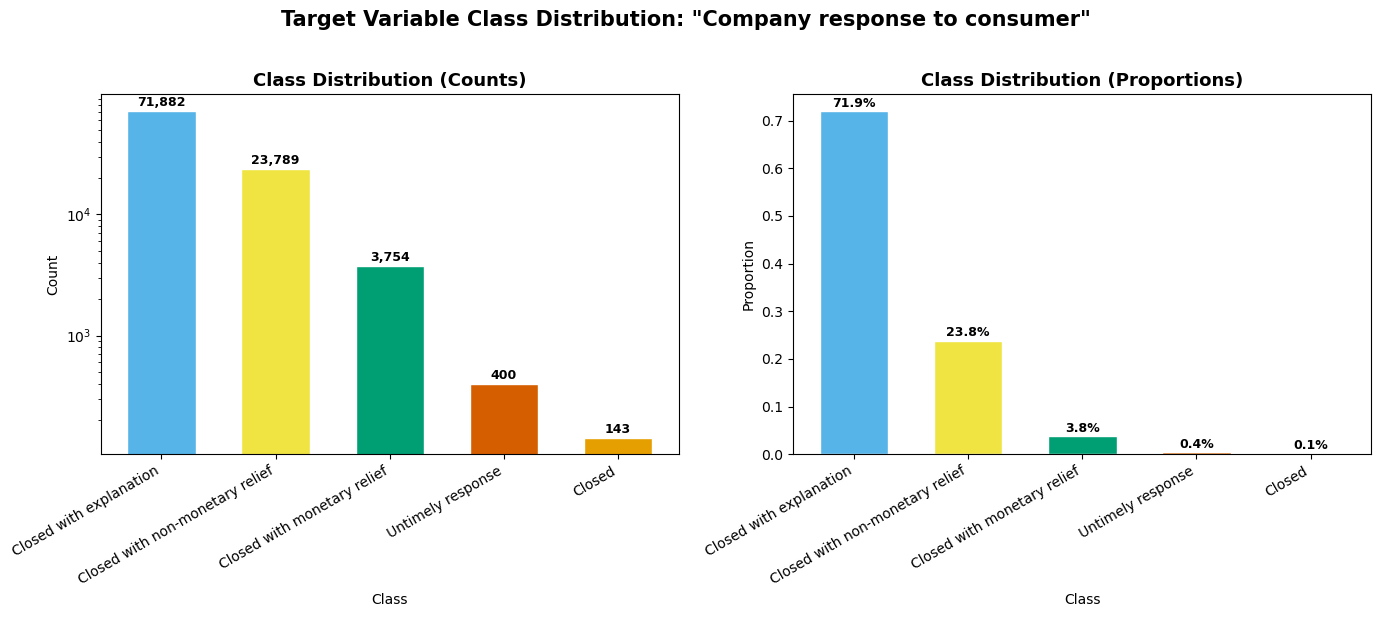

In [27]:
class_distribution_plot(data)

In [ ]:
"""Analysis
From target variable distribution I spot the class imbalance, which means I will need to use class imbalance techniques. 
I decided to use class weighting because there is severe class imabalance: 71.9% against 0.1%, 
that's a 700x ratio, and SMOTE techniques(e.x. undersampling) would have to create a lot of syntetic samples and discard the real training data. 
"""

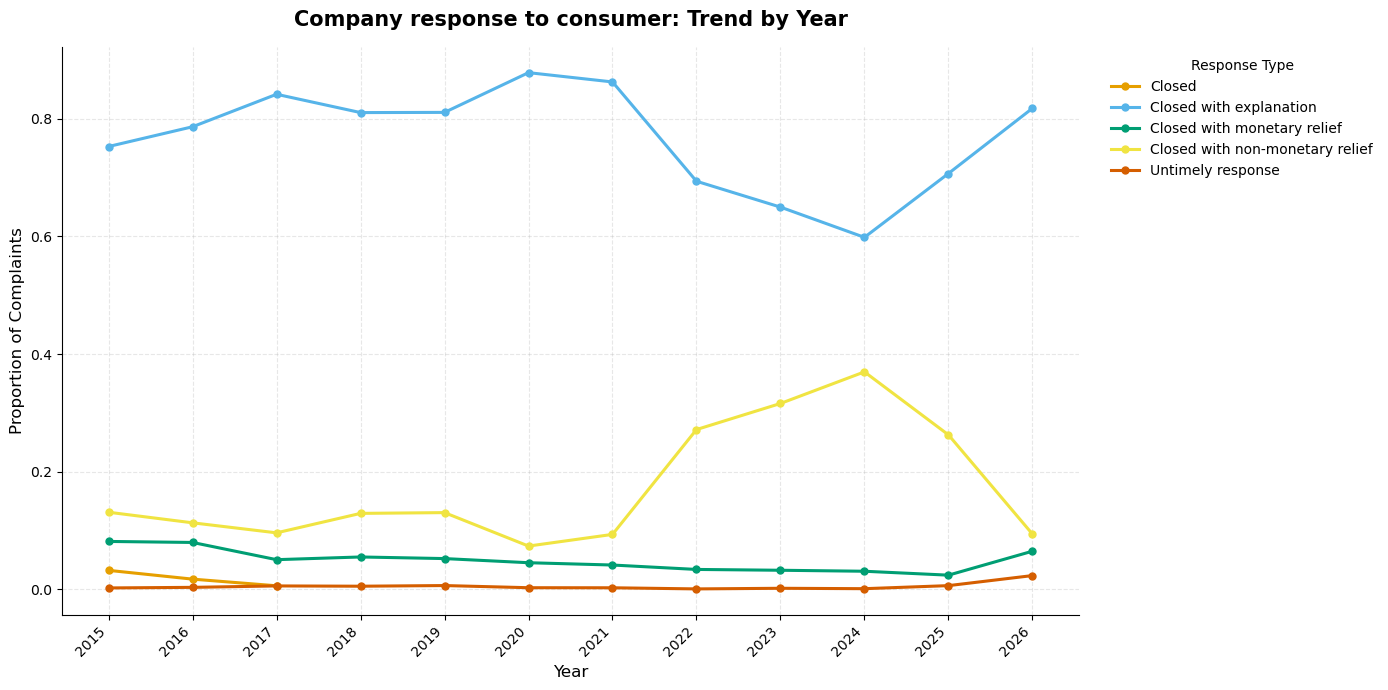

Company response to consumer,Closed,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,Untimely response
year,,,,,
2015,0.032289,0.752771,0.081446,0.131084,0.002410
2016,0.017376,0.786371,0.079727,0.113118,0.003407
2017,0.006065,0.841582,0.050461,0.096070,0.005822
2018,NaN,0.810453,0.055052,0.129152,0.005343
2019,NaN,0.810786,0.052316,0.130445,0.006453
2020,NaN,0.878343,0.045272,0.073589,0.002797
2021,NaN,0.862541,0.041357,0.093425,0.002678
2022,NaN,0.693742,0.033860,0.271638,0.000761
2023,NaN,0.649760,0.032455,0.315966,0.001819


In [31]:
data['Date received'] = pd.to_datetime(data['Date received'], format='mixed', utc=True)
class_distribution_over_time(data)

In [ ]:
"""Analysis
1. "Closed" response type existed only from 2015 to 2017. Then there was a slight rise from 2019 to 2020 with "Closed with explanation response", which means companies tried to give more explanations to consumers. Which meanwhile also increased the "Closed with non-monetary relief". 
From 2021 to 2024 "Closed with non-monetary relief" type increased quite rapidly. Something has changed how companies view their policity in those three years because while "Closed with non-monetary relief" increased, "Closed with explanation" suddenly started dropping. 
In 2024 the lowest point of "Closed with explanation" and the lowest point of "Closed with non-monetary relief" align. 


"""

Product vs Sub-product missingness: how much of this column is missing overall, and whether it's missing systematically by Product (some products might just not have sub-categories) rather than randomly.

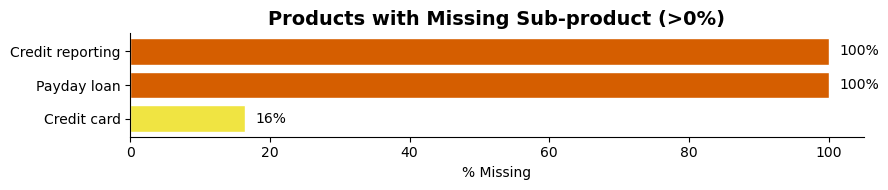

Product
Credit reporting    100.000000
Payday loan         100.000000
Credit card          16.485467
Name: is_missing, dtype: float64

In [40]:
sub_product_missing_values(data)

In [ ]:
"""
Everytime there is a Product of Credit reporting or Payday loan, the Sub-product is missing. 
It can indicate that those products does not have the Sub-product at all. 

Credit card is the only Product where sometimes the Sub-Product is not filled in. 
"""

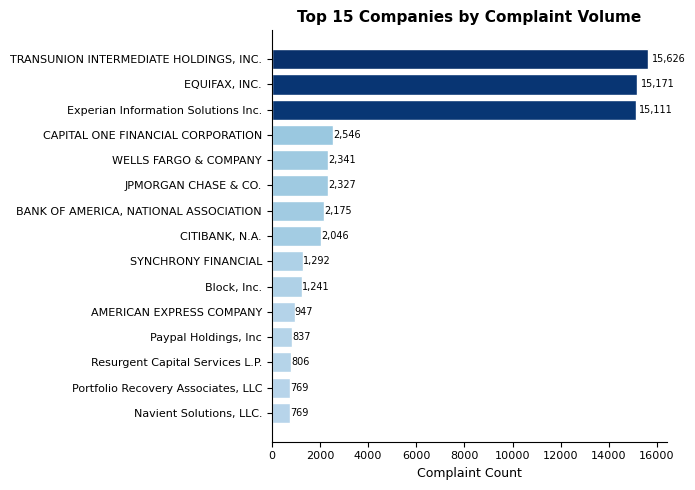

Company
Navient Solutions, LLC.                     769
Portfolio Recovery Associates, LLC          769
Resurgent Capital Services L.P.             806
Paypal Holdings, Inc                        837
AMERICAN EXPRESS COMPANY                    947
Block, Inc.                                1241
SYNCHRONY FINANCIAL                        1292
CITIBANK, N.A.                             2046
BANK OF AMERICA, NATIONAL ASSOCIATION      2175
JPMORGAN CHASE & CO.                       2327
WELLS FARGO & COMPANY                      2341
CAPITAL ONE FINANCIAL CORPORATION          2546
Experian Information Solutions Inc.       15111
EQUIFAX, INC.                             15171
TRANSUNION INTERMEDIATE HOLDINGS, INC.    15626
Name: count, dtype: int64

In [ ]:

top_companies_by_complaint(data)

In [ ]:
"""
There are three companies which have the most complaints: TRANSUNION INTERMEDIATE HOLDINGS, INC., EQUIFAX, INC., and Experian Information Solutions Inc.
They rougly have similar amount of complaints.
"""

In [123]:
print(data['Submitted via'].value_counts())
print(data['Submitted via'].nunique())

Submitted via
Web    99968
Name: count, dtype: int64
1


There is only one unique value in the `Submitted via`, which is `Yes`. 

My decision is to delete this feature because it doesn't carry any important information and only increaded dimensionality. 

## Percentage and amount of missing values in columns

In [75]:
is_nan = data.isna()
is_blank = data.select_dtypes(include='object').apply(lambda col: col.astype(str).str.strip() == "")

missing_count = is_nan.sum().add(is_blank.reindex(columns=data.columns, fill_value=0).sum(), fill_value=0)
missing_percentage = missing_count / len(data) * 100

missing_report = pd.DataFrame({
    'missing_count': missing_count.astype(int),
    'missing_percentage': missing_percentage
}).sort_values('missing_count', ascending=False)

print(missing_report)

                              missing_count  missing_percentage
Tags                                  86859           86.886804
Company public response               49508           49.523848
Sub-issue                             11853           11.856794
Sub-product                            1934            1.934619
State                                   395            0.395126
ZIP code                                  4            0.004001
Date received                             0            0.000000
Product                                   0            0.000000
Issue                                     0            0.000000
Consumer complaint narrative              0            0.000000
Company                                   0            0.000000
Submitted via                             0            0.000000
Date sent to company                      0            0.000000
Company response to consumer              0            0.000000
Timely response?                        

The most amount of missing values are in the `Tags` column. That's 86 percents. 

I decided to drop this column later on because if I would be to replace it with syntetic data, the noise would arise in the training set. 

I decided also to drop `Company public response` because its meaning similar to the target variable `Company response to consumer` (it gives broader explanation of why the company replied to consumer in a certain way). To avoid data leakage I will remove this feature from input set. It also has almost 50% of missing values which 

I decided to leave `Sub-issue`, `Sub-product`, and `State` as input features for now. Since they are categorical features, I decided to replace missing values in them with "Unknown" because at least for `Sub-product` I found out that values are mot missing at random. 

`Complaint ID` doesn't have any important information for the models because it is just an identification of the complaint, so I will drop this feature too. 

Text features are `Consumer complaint narrative` and target variable `Company response to consumer`. 

I will tokenize them(word tokenization), then remove stop words, conduct lemmatization and as final step vectorize them with TF-IDF. 

I will not use any scaler here for encoded features because scaling is done only on raw numerical features.

`Date received` and `Date sent to the company` are datetime features. 

I decided to create two separate input features from two of those: `processing time` and `year`.

Since in the Line chart there was a clear relation with year and certain target value, it could be uselful and I cannot include datetime type into the model as raw values. Processing time can give the model the opportunity to learn relationships between how processing time and output relate to each other

## Text features analysis

### N-grams for Consumer complaint narrative

In [77]:
top_bigrams = top_ngrams(data['Consumer complaint narrative'], n=2, top_k=20)
for phrase, count in top_bigrams:
    print(f"{phrase}: {count:,}")

xxxx xxxx: 1,127,858
xx xx: 146,620
xx xxxx: 110,377
credit report: 62,205
xxxx xx: 36,292
xxxx account: 35,608
credit reporting: 33,189
account xxxx: 25,658
xxxxxxxx xxxx: 23,461
identity theft: 23,277
xxxx xxxxxxxx: 22,986
fair credit: 20,876
number xxxx: 20,640
consumer reporting: 20,458
00 xxxx: 20,140
account number: 19,997
reporting act: 19,825
reporting agency: 19,250
15 usc: 17,032
xxxx balance: 16,817


In [78]:
top_trigrams = top_ngrams(data['Consumer complaint narrative'], n=3, top_k=20)
for phrase, count in top_trigrams:
    print(f"{phrase}: {count:,}")

xxxx xxxx xxxx: 865,361
xx xx xxxx: 106,855
xxxx xx xx: 36,286
xx xxxx xxxx: 24,414
fair credit reporting: 19,835
credit reporting act: 19,663
xxxx xxxx account: 19,579
xxxx xxxx xx: 18,567
consumer reporting agency: 16,350
xxxxxxxx xxxx xxxx: 15,307
account number xxxx: 15,217
xxxx xxxx xxxxxxxx: 14,951
00 xxxx xxxx: 14,405
xxxx account number: 14,198
account xxxx xxxx: 13,781
xx xx year: 12,844
xxxx xxxxxxxx xxxx: 12,464
xxxx account xxxx: 11,626
opened xx xx: 10,157
xxxx xxxx date: 8,661


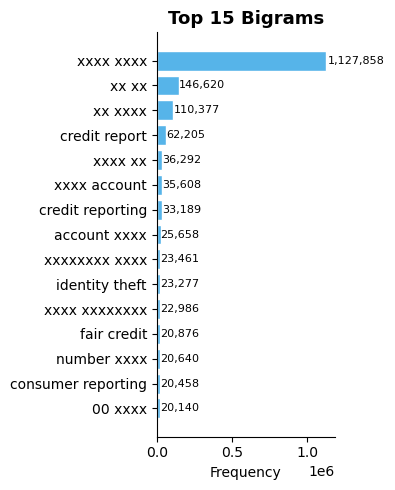

In [80]:
plot_top_ngrams(data['Consumer complaint narrative'], n=2)

I will take into account during stopwords removal, that `xxxx xxxx` should be handled as well. Those values represent the confidential information of consumers. 

### N-grams for Consumer complaint narrative after stopwords removal, so `XXXX XXXX` won't show 
#### Most frequent words after stopwords removal

In [ ]:
stop_words = set(stopwords.words('english'))

In [92]:
cleaned_texts = (
    data['Consumer complaint narrative']
    .apply(lambda t: re.sub(r'\bx{2,}\b', '', t, flags=re.IGNORECASE))
    .apply(tokenize)
    .apply(remove_stopwords)
    .apply(lambda tokens: " ".join(tokens))   # convert list to string because plot() won't work if it's a list
)

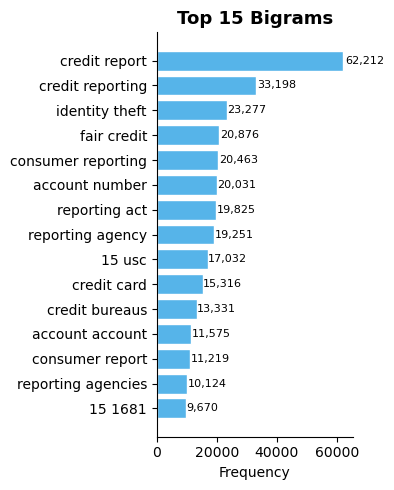

In [93]:
plot_top_ngrams(cleaned_texts, n=2)

## Vocabulary size 

In [94]:
all_tokens = (
    data['Consumer complaint narrative']
    .apply(lambda t: re.sub(r'\bx{2,}\b', '', t, flags=re.IGNORECASE))
    .apply(tokenize)
    .apply(remove_stopwords)
)

vocabulary = set()
for token_list in all_tokens:
    vocabulary.update(token_list)

print(f"Total unique vocabulary size: {len(vocabulary):,}")

Total unique vocabulary size: 80,333


In [ ]:


word_counts = Counter()
for token_list in all_tokens:
    word_counts.update(token_list)

hapax_count = sum(1 for word, count in word_counts.items() if count == 1)
rare_count = sum(1 for word, count in word_counts.items() if count <= 5)

print(f"Words appearing only once: {hapax_count:,} ({hapax_count/len(vocabulary)*100:.1f}% of vocabulary)")
print(f"Words appearing 5 times or fewer: {rare_count:,} ({rare_count/len(vocabulary)*100:.1f}% of vocabulary)")

Words appearing only once: 43,744 (54.5% of vocabulary)
Words appearing 5 times or fewer: 61,850 (77.0% of vocabulary)


Since the total unique vocabulary size is 80,333 it could be useful for TF-IDF vectorization max_features selection. 

Max_features could be set between 10,000 and 20,000. Because 77% of the vocabulary appears less than 5 times (5 times I chose as threshold to indicate its uniqueness). I will set max_features in vectorization to 15,000. 



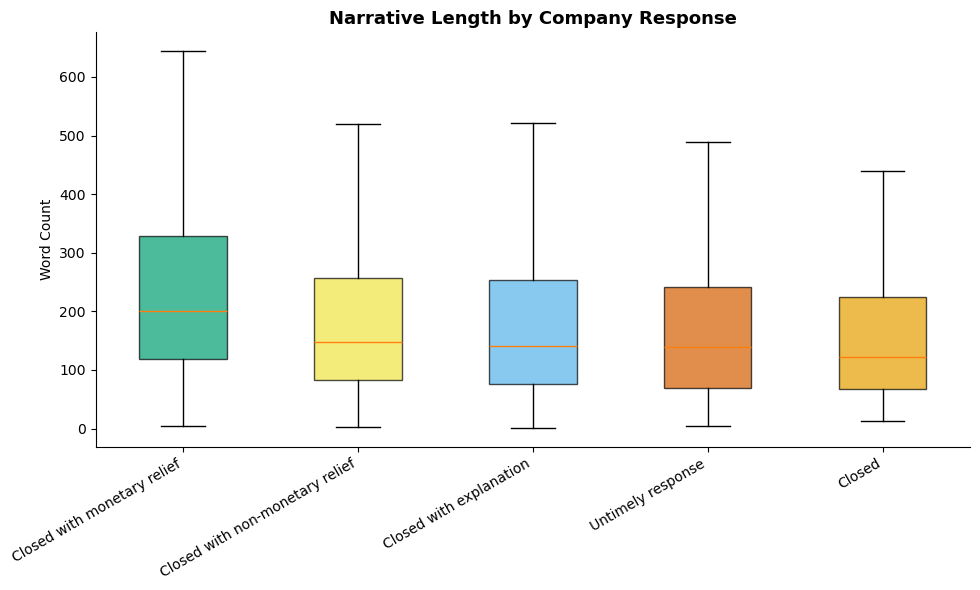

Company response to consumer
Closed with monetary relief        200.0
Closed with non-monetary relief    148.0
Closed with explanation            141.0
Untimely response                  139.0
Closed                             122.0
Name: word_count, dtype: float64


In [98]:
narrative_length_by_target(data)

Complaints that led to monetary relief tend to have more words than the other categories, and their length also varies more. 

More detailed complaints may be linked to better outcomes for the consumer, so word count could be a useful feature to add to the classical models.

I will add `word count` of `Consumer complaint narrative` as input feature because of that. Later I will use Decision Trees for feature importance and in order to avoid confusion (Decision Trees are prone to overfitting), I'll use SHAP as additional back up for feature importance conclusions. 

Based on those, I'll make a decision about input features for models.

## Outliers detection

### Very short consumer complaints

In [124]:
short_complaints = data[data['word_count'] <= 3]

print(f"Complaints with 3 words or fewer: {len(short_complaints):,} ({len(short_complaints)/len(data)*100:.2f}%)")
print()
print(short_complaints[['word_count', 'Consumer complaint narrative']].head(10))

Complaints with 3 words or fewer: 24 (0.02%)

       word_count Consumer complaint narrative
489             3             Balance was paid
2730            2        wrongful foreclosure,
4619            3         Equifax data breach.
9750            2      Unauthorized Inquiries.
10433           2             NO INVESTIGATION
14447           2                 XXXX breach.
18428           3         Please see attached.
20978           3               Debt was paid,
21240           3      Reporting late payments
24082           3      BEING DENIED EMPLOYMENT


### Very long consumer complaints

In [ ]:
long_complaints = data[data['word_count'] > 526] 

print(f"Complaints over 526 words: {len(long_complaints):,} ({len(long_complaints)/len(data)*100:.2f}%)")
print()
print(long_complaints[['word_count', 'Company response to consumer']].sort_values('word_count', ascending=False).head(10))

Complaints over 526 words: 6,517 (6.52%)

       word_count     Company response to consumer
7711         6218          Closed with explanation
29105        5862          Closed with explanation
40659        5847          Closed with explanation
37494        5714          Closed with explanation
89715        5709  Closed with non-monetary relief
41555        5678          Closed with explanation
66750        5557          Closed with explanation
38942        5472          Closed with explanation
23756        5405          Closed with explanation
92205        5307  Closed with non-monetary relief


In [ ]:
print(long_complaints['Company response to consumer'].value_counts(normalize=True))
print(data['Company response to consumer'].value_counts(normalize=True)) 

Company response to consumer
Closed with explanation            0.709836
Closed with non-monetary relief    0.226024
Closed with monetary relief        0.060611
Untimely response                  0.002915
Closed                             0.000614
Name: proportion, dtype: float64
Company response to consumer
Closed with explanation            0.719050
Closed with non-monetary relief    0.237966
Closed with monetary relief        0.037552
Untimely response                  0.004001
Closed                             0.001430
Name: proportion, dtype: float64


## Outliers of numerical features

In [105]:
data = add_word_count_feature(data)

In [108]:
q1 = data['word_count'].quantile(0.25)
q3 = data['word_count'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = data[data['word_count'] > upper_bound]
print(f"Upper bound: {upper_bound:.0f} words")
print(f"Outliers above bound: {len(outliers):,} ({len(outliers)/len(data)*100:.1f}% of data)")
print(f"Max word count: {data['word_count'].max():,}")
print(data['word_count'].describe())

Upper bound: 526 words
Outliers above bound: 6,540 (6.5% of data)
Max word count: 6,218
count    99968.000000
mean       209.571773
std        247.051079
min          1.000000
25%         78.000000
50%        145.000000
75%        257.000000
max       6218.000000
Name: word_count, dtype: float64


There are some outlier amount in the data, which indicates at very long complaints (longer narratives correlate with monetary-relief outcomes). 

## Time-Series Analysis